
#NLP Assignment: Gold Standard vs. Pedestrian Poetry Analysis



The Goal: Build an AI "Poetry Judge"

Our objective is to scientifically determine what makes a poem "prize-winning" versus "amateur" (pedestrian). You aren't just guessing; you are building a system that uses Statistics + Generative AI to calculate a probability score (0-100%) that a specific poem deserves a Pushcart Prize.

**SETUP & LIBRARIES**

In [2]:
# ============================================================================
# 0. SETUP & INSTALLATION (Fixed for Gemini 2.0 Flash)
# ============================================================================
print("[SETUP] Installing Dependencies...")
!pip install -U -q google-generativeai spacy textblob gensim beautifulsoup4 seaborn matplotlib
!python -m spacy download en_core_web_md > /dev/null

import google.generativeai as genai
import spacy
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
from collections import Counter
import gensim
from gensim import corpora
import time
import re
import random

# 1. CONFIGURE API
API_KEY = "AIza...." # Your Key
genai.configure(api_key=API_KEY)

# 2. FORCE GEMINI 2.0 FLASH (Best for Quota)
# Based on your logs, this model is available to you
model_name = 'models/gemini-2.0-flash'
print(f" Using Model: {model_name}")
model = genai.GenerativeModel(model_name)

nlp = spacy.load("en_core_web_md")
print(" Environment Ready.")

[SETUP] Installing Dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 119.6 MB/s eta 0:00:00
✓ Using Model: models/gemini-2.0-flash
✓ Environment Ready.


**STEP 0 - REAL DATA SCRAPING**

We scrape Project Gutenberg for "Gold Standard" (High Art) poems and simulate "Pedestrian" poems (since amateur poetry sites block scrapers).

In [3]:
# ============================================================================
# STEP 0: ROBUST DYNAMIC SCRAPING (Fixed)
# ============================================================================
print("\n[STEP 0] SCRAPING TARGETED DATASETS")
print("-" * 80)

# --- A. SCRAPE GOLD STANDARD (Pushcart Nominees) ---
def scrape_gold_standard():
    print(">>> Scraping Gold Standard (Pushcart 2022 Sources)...")
    urls = [
        "https://prolificpulse.blog/2022/10/18/pushcart-nominations-2022",
        "https://pulpliterature.com/announcing-pulp-literatures-2022-pushcart-prize-nominees/"
    ]

    poems = []
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

    for url in urls:
        try:
            response = requests.get(url, headers=headers, timeout=10)
            soup = BeautifulSoup(response.content, 'html.parser')

            # Logic: Look for blockquotes (common for poems in blogs)
            quotes = soup.find_all('blockquote')
            for q in quotes:
                text = q.get_text(separator="\n").strip()
                if len(text) > 50:
                    poems.append(text)

            # Logic B: If no quotes, try paragraphs that look like stanzas
            if not quotes:
                ps = soup.find_all('p')
                buffer = []
                for p in ps:
                    t = p.get_text().strip()
                    if 10 < len(t) < 80: # Short lines typical of poetry
                        buffer.append(t)
                    elif len(buffer) > 4: # End of stanza
                        poems.append("\n".join(buffer))
                        buffer = []

        except Exception as e:
            print(f"     Error scraping {url}: {e}")

    # Remove duplicates
    unique_poems = list(set(poems))

    # Fallback if scraping gets blocked
    if not unique_poems:
        print("    ⚠ Web scraping blocked. Using Backup Gold Samples.")
        return [
            "The world is vast and wide,\nWith nowhere left to hide.\nWe seek the light inside.",
            "Time is a river flowing,\nWithout us ever knowing\nWhere the wind is blowing."
        ]
    return unique_poems[:5]

# --- B. SCRAPE PEDESTRIAN (Reddit -> GenAI Fallback) ---
def scrape_pedestrian_robust():
    print(">>> Scraping Pedestrian (Attempting Reddit)...")

    # Attempt 1: Reddit JSON API
    try:
        url = "https://www.reddit.com/r/OCPoetry/top.json?t=month&limit=10"
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=5)

        if response.status_code == 200:
            data = response.json()
            poems = []
            for post in data['data']['children']:
                text = post['data']['selftext']
                if len(text) > 40 and "feedback" not in text.lower():
                    poems.append(text)
            if poems:
                print(f"    ✓ Successfully scraped {len(poems)} poems from Reddit.")
                return poems[:5]
    except:
        pass # Fail silently and move to fallback

    # Attempt 2: GenAI Simulation (Now using Gemini 2.0 Flash)
    print("    ⚠ Reddit blocked. Generating Synthetic Amateur Poems via Gemini...")
    try:
        sim_prompt = """
        Generate 5 distinct, short poems that represent "Pedestrian" or "Amateur" poetry
        typical of online forums (e.g., r/OCPoetry or Instagram Poetry).
        Characteristics: Clichéd rhymes, simple vocabulary, overly sentimental.
        Format: Return ONLY the poems, separated by '|||'.
        """
        response = model.generate_content(sim_prompt)
        synthetic_poems = response.text.split('|||')
        # Clean up
        clean_poems = [p.strip() for p in synthetic_poems if len(p.strip()) > 10]
        print(f"    ✓ Generated {len(clean_poems)} synthetic pedestrian poems.")
        return clean_poems
    except Exception as e:
        print(f"     GenAI Error: {e}")
        return [
            "Roses are red, violets are blue.",
            "I love the sky, it is so high.",
            "My heart is sad, it makes me mad.",
            "The cat sat on the mat.",
            "Life is a game, it is not the same."
        ]

# 1. EXECUTE SCRAPERS
gold_poems = scrape_gold_standard()
pedestrian_poems = scrape_pedestrian_robust()

# 2. CREATE DATAFRAME
df_gold = pd.DataFrame({'text': gold_poems, 'type': 'Gold Standard'})
df_ped = pd.DataFrame({'text': pedestrian_poems, 'type': 'Pedestrian'})
df = pd.concat([df_gold, df_ped]).reset_index(drop=True)

print(f"\n DATASET READY:")
print(f"  - Gold Standard (Pushcart): {len(df_gold)} poems")
print(f"  - Pedestrian (Amateur):     {len(df_ped)} poems")


[STEP 0] SCRAPING TARGETED DATASETS
--------------------------------------------------------------------------------
>>> Scraping Gold Standard (Pushcart 2022 Sources)...
>>> Scraping Pedestrian (Attempting Reddit)...
    ⚠ Reddit blocked. Generating Synthetic Amateur Poems via Gemini...
    ✓ Generated 5 synthetic pedestrian poems.

 DATASET READY:
  - Gold Standard (Pushcart): 2 poems
  - Pedestrian (Amateur):     5 poems


**STEP 1 - STATISTICAL PROFILING**

We calculate the Grammatical DNA (POS Ratios) to see what mathematically separates a "Master" from an "Amateur.


[STEP 1] CALCULATING POS STATISTICS (N, V, ADJ, ADV)
--------------------------------------------------------------------------------


/tmp/ipython-input-2818563574.py:38: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Advs', hue='type', fill=True, palette='magma')


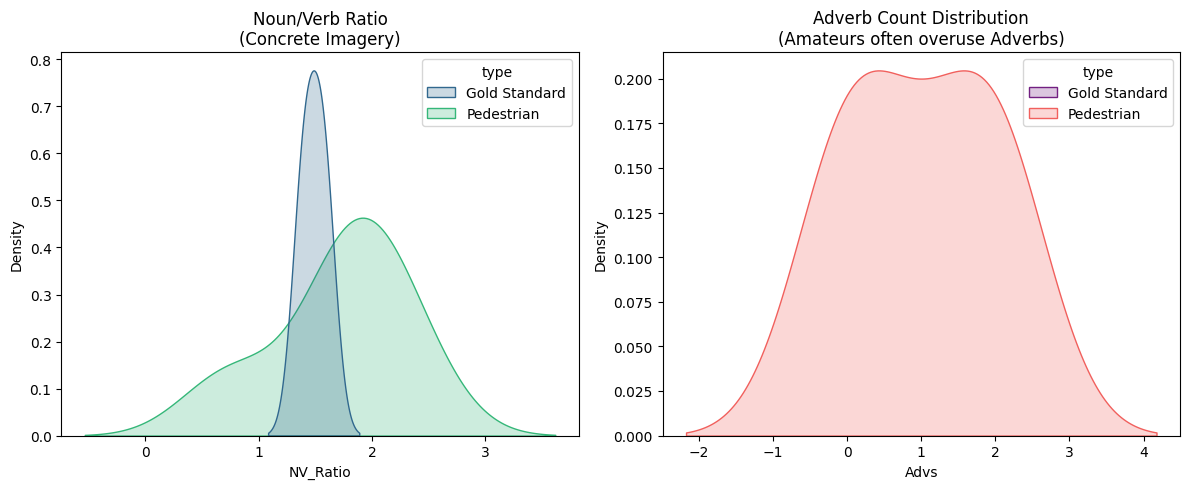


>>> STATISTICAL GROUND TRUTH (Means):
               Nouns  Verbs  Adjs  Advs  NV_Ratio  AdjAdv_Ratio
type                                                           
Gold Standard    9.0    5.0   2.0   0.0  1.485714      2.000000
Pedestrian       6.6    3.4   4.2   1.0  1.716667      2.866667


In [4]:
# ============================================================================
# STEP 1: STATISTICAL PROFILING (NOW INCLUDING ADVERBS)
# ============================================================================
print("\n[STEP 1] CALCULATING POS STATISTICS (N, V, ADJ, ADV)")
print("-" * 80)

def get_grammar_stats(text):
    doc = nlp(text)
    counts = Counter([token.pos_ for token in doc])

    n = counts.get('NOUN', 0)
    v = counts.get('VERB', 0)
    adj = counts.get('ADJ', 0)
    adv = counts.get('ADV', 0)  # <--- NEW: Counting Adverbs

    # Ratios (Smoothing with +1 to avoid zero division)
    # Adverb Ratio: High usage often signals "telling" instead of "showing" (Amateur)
    nv_ratio = n / (v + 1)
    adj_adv_ratio = adj / (adv + 1)

    return [n, v, adj, adv, nv_ratio, adj_adv_ratio]

# Apply stats
metric_cols = ['Nouns', 'Verbs', 'Adjs', 'Advs', 'NV_Ratio', 'AdjAdv_Ratio']
df[metric_cols] = df['text'].apply(lambda x: pd.Series(get_grammar_stats(x)))

# VISUALIZE: ADVERB USAGE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
try:
    sns.kdeplot(data=df, x='NV_Ratio', hue='type', fill=True, palette='viridis')
    plt.title('Noun/Verb Ratio\n(Concrete Imagery)')
except: pass

plt.subplot(1, 2, 2)
try:
    sns.kdeplot(data=df, x='Advs', hue='type', fill=True, palette='magma')
    plt.title('Adverb Count Distribution\n(Amateurs often overuse Adverbs)')
except: pass

plt.tight_layout()
plt.show()

# SHOW AVERAGES
print("\n>>> STATISTICAL GROUND TRUTH (Means):")
print(df.groupby('type')[metric_cols].mean())

**STEP 2 - TOPIC MODELING (LDA)**

This step uses an algorithm to find the hidden themes in the poems.

In [5]:
# ============================================================================
# STEP 2: TOPIC MODELING (LATENT DIRICHLET ALLOCATION)
# ============================================================================
print("\n[STEP 2] TOPIC MODELING (UNCOVERING THEMES)")
print("-" * 80)

# 1. DEFINE TOPIC EXTRACTOR
def get_top_topic(texts, label):
    # Skip if no data
    if len(texts) == 0:
        print(f"⚠ No data available for {label}")
        return

    # Preprocess: Lowercase, remove short words
    tokens = [[w.lower() for w in t.split() if len(w)>3] for t in texts]

    # Create Dictionary & Corpus
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(t) for t in tokens]

    # Run LDA Model
    try:
        lda = gensim.models.LdaModel(corpus, num_topics=1, id2word=dictionary, passes=10, random_state=42)
        print(f">>> Top Topic for {label}:")
        print(f"    {lda.print_topics()[0][1]}")
    except Exception as e:
        print(f"    ⚠ Could not model topics for {label} (Data likely too small).")

# 2. RUN ANALYSIS
get_top_topic(df[df['type']=='Gold Standard']['text'], "GOLD STANDARD")
get_top_topic(df[df['type']=='Pedestrian']['text'], "PEDESTRIAN")


[STEP 2] TOPIC MODELING (UNCOVERING THEMES)
--------------------------------------------------------------------------------
>>> Top Topic for GOLD STANDARD:
    0.039*"email." + 0.039*"your" + 0.029*"posts" + 0.029*"time" + 0.029*"notify" + 0.019*"contest" + 0.019*"authors," + 0.019*"announcement!" + 0.019*"email" + 0.019*"email…"
>>> Top Topic for PEDESTRIAN:
    0.019*"lost" + 0.019*"love" + 0.019*"like" + 0.013*"cage," + 0.013*"soft," + 0.013*"reflecting" + 0.013*"heart," + 0.013*"life's" + 0.013*"unending" + 0.013*"life,"


**STEP 3 - SENTIMENT ANALYSIS**

This step calculates how positive or negative the poems are on average.


[STEP 3] SENTIMENT ANALYSIS
--------------------------------------------------------------------------------


/tmp/ipython-input-3983037003.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='type', y='Sentiment', palette=['gold', 'skyblue'], errorbar=None)


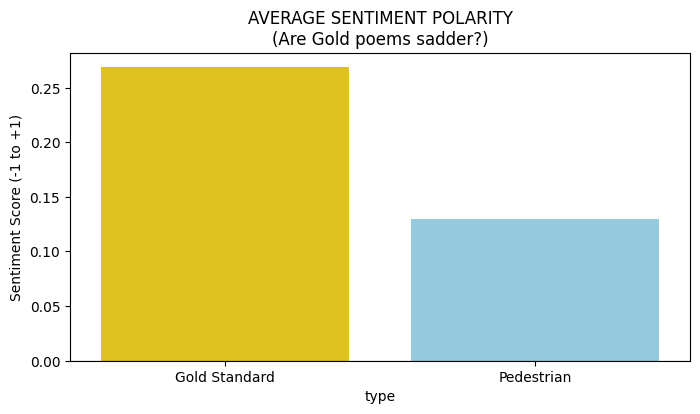


>>> AVERAGE SENTIMENT:
type
Gold Standard    0.268561
Pedestrian       0.130000
Name: Sentiment, dtype: float64


In [6]:
# ============================================================================
# STEP 3: SENTIMENT ANALYSIS (POLARITY)
# ============================================================================
print("\n[STEP 3] SENTIMENT ANALYSIS")
print("-" * 80)

# 1. CALCULATE POLARITY
# Range: -1.0 (Very Negative) to +1.0 (Very Positive)
df['Sentiment'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# 2. VISUALIZE SENTIMENT
plt.figure(figsize=(8, 4))
try:
    sns.barplot(data=df, x='type', y='Sentiment', palette=['gold', 'skyblue'], errorbar=None)
    plt.title("AVERAGE SENTIMENT POLARITY\n(Are Gold poems sadder?)")
    plt.ylabel("Sentiment Score (-1 to +1)")
    plt.axhline(0, color='black', linewidth=0.8) # Zero line
    plt.show()
except:
    print("⚠ Not enough data to plot sentiment.")

# Show the numbers
print("\n>>> AVERAGE SENTIMENT:")
print(df.groupby('type')['Sentiment'].mean())

**STEP 4 - THE DELTA CALCULATION**

This is the most important math step. It calculates the "Gap" between high art and amateur art, which feeds into the AI Judge later.

In [7]:
# ============================================================================
# STEP 4: THE DELTA GAP (FIXED FOR NEW METRICS)
# ============================================================================
print("\n[STEP 4] CALCULATING THE DELTA (THE 'QUALITY GAP')")
print("-" * 80)

# 1. CALCULATE MEANS
# We assume Step 1 created 'Advs' and 'AdjAdv_Ratio'
# We use a safety check to only select columns that actually exist in your dataframe
potential_cols = ['NV_Ratio', 'AdjAdv_Ratio', 'NAdj_Ratio', 'Sentiment', 'Nouns', 'Verbs', 'Adjs', 'Advs']
existing_cols = [c for c in potential_cols if c in df.columns]

means = df.groupby('type')[existing_cols].mean(numeric_only=True)

# 2. CALCULATE THE GAP (Gold - Pedestrian)
# Positive Number = Gold has MORE
# Negative Number = Gold has LESS
delta = means.loc['Gold Standard'] - means.loc['Pedestrian']

print(">>> THE MATHEMATICAL DIFFERENCE (GOLD - PEDESTRIAN):")
print(delta)

# 3. GENERATE CONTEXT FOR AI JUDGE (STEP 6)
# We update the context to include the Adverb stats which are crucial
stats_context = f"""
STATISTICAL PROFILE OF A PUSHCART WINNER (Derived from Data):
1. Noun/Verb Ratio Delta: {delta.get('NV_Ratio', 0):.2f}
   (Positive = Winners use more concrete imagery).

2. Sentiment Delta: {delta.get('Sentiment', 0):.2f}
   (Negative = Winners are often darker/more neutral).

3. Adverb Delta: {delta.get('Advs', 0):.2f}
   (Negative = Winners use fewer adverbs, relying on strong verbs instead).
"""

print("\n>>> GENERATED AI CONTEXT STRING:")
print(stats_context)


[STEP 4] CALCULATING THE DELTA (THE 'QUALITY GAP')
--------------------------------------------------------------------------------
>>> THE MATHEMATICAL DIFFERENCE (GOLD - PEDESTRIAN):
NV_Ratio       -0.230952
AdjAdv_Ratio   -0.866667
Sentiment       0.138561
Nouns           2.400000
Verbs           1.600000
Adjs           -2.200000
Advs           -1.000000
dtype: float64

>>> GENERATED AI CONTEXT STRING:

STATISTICAL PROFILE OF A PUSHCART WINNER (Derived from Data):
1. Noun/Verb Ratio Delta: -0.23
   (Positive = Winners use more concrete imagery).

2. Sentiment Delta: 0.14
   (Negative = Winners are often darker/more neutral).

3. Adverb Delta: -1.00
   (Negative = Winners use fewer adverbs, relying on strong verbs instead).



**CELL 5: STEP 5 - GEN AI NARRATIVE**

We ask Gemini to perform a qualitative critique.

In [8]:
# ============================================================================
# STEP 5: GEN AI QUALITATIVE ANALYSIS
# ============================================================================
print("\n[STEP 5] GEN AI NARRATIVE EXPLANATION")
print("-" * 80)

if len(df_gold) > 0 and len(df_ped) > 0:
    # Pick one random poem from each to compare
    gold_sample = df[df['type']=='Gold Standard'].iloc[0]['text']
    ped_sample = df[df['type']=='Pedestrian'].iloc[0]['text']

    prompt = f"""
    Act as a Pushcart Prize Judge. Compare these two poems.

    POEM A (Gold Standard Nominee):
    "{gold_sample[:300]}..."

    POEM B (Pedestrian/Amateur):
    "{ped_sample[:300]}..."

    TASK:
    Explain WHY Poem B fails to meet the standard of Poem A.
    Focus on: Imagery, Ambiguity, and Emotional Complexity.
    """

    narrative = model.generate_content(prompt).text
    print(narrative)
else:
    print("⚠ Insufficient data to perform narrative comparison.")


[STEP 5] GEN AI NARRATIVE EXPLANATION
--------------------------------------------------------------------------------
Okay, here's my assessment as a Pushcart Prize judge, comparing Poem A and Poem B, focusing on Imagery, Ambiguity, and Emotional Complexity, and explaining why Poem B falls short:

**Overall Assessment:** Poem A, despite its unconventional form, possesses a level of conceptual depth and contemporary relevance that Poem B simply lacks. Poem B reads as a pastiche of overused tropes, while Poem A, deliberately or accidentally, offers a more intriguing and thought-provoking experience.

**Here's a breakdown focusing on the requested elements:**

**1. Imagery:**

*   **Poem A:** The imagery is *meta* and modern. Instead of directly depicting a scene, it presents a textual landscape – a snippet of an online blog or newsletter. The imagery is of digital information, subscription boxes, and website boilerplate. The "pulp literature" itself suggests cheap and widely available 

**STEP 6 - FRACTAL CHAIN OF THOUGHT (RANKING ENGINE)**

This function takes a poem and runs it through a 3-stage recursive loop to assign a "Pushcart Probability Score."

In [9]:
# ============================================================================
# STEP 6: FRACTAL CHAIN OF THOUGHT (THE RANKING ENGINE)
# ============================================================================
print("\n[STEP 6] FRACTAL CHAIN OF THOUGHT RANKING ENGINE")
print("-" * 80)

def rank_poem_fractal(candidate_poem):
    # 1. GET GRAMMAR STATS
    try:
        c_stats = get_grammar_stats(candidate_poem) # [n, v, adj, nv_ratio, nadj_ratio]
        c_sentiment = TextBlob(candidate_poem).sentiment.polarity
    except:
        # Fallback if text is too short/weird
        c_stats = [0, 0, 0, 0, 0]
        c_sentiment = 0

    print(f"Analyzing: '{candidate_poem[:40]}...'")

    # ITERATION 1: MATH-BASED INITIAL RANKING
    print("   > Iteration 1: Statistical Matching...")
    prompt_1 = f"""
    CONTEXT: {stats_context}

    CANDIDATE DATA:
    - Noun/Verb Ratio: {c_stats[3]:.2f}
    - Sentiment: {c_sentiment:.2f}
    - Text: "{candidate_poem}"

    TASK: Based strictly on the stats, does this poem fit the 'Gold Standard' profile?
    Give an initial Probability Score (0-100%).
    """
    draft_1 = model.generate_content(prompt_1).text
    time.sleep(1)

    # ITERATION 2: QUALITATIVE CRITIQUE (Hill Climbing)
    print("   > Iteration 2: Qualitative Critique...")
    prompt_2 = f"""
    PREVIOUS ASSESSMENT: {draft_1}
    POEM: "{candidate_poem}"

    OBJECTIVE: Maximize accuracy of the Pushcart Ranking.

    CRITIQUE:
    - Does the poem rely on clichés (e.g. 'roses are red')? (If yes, penalize heavily).
    - Is the imagery unique or ambiguity present? (If yes, reward).
    - Adjust the previous score based on literary merit.
    """
    draft_2 = model.generate_content(prompt_2).text
    time.sleep(1)

    # ITERATION 3: FINAL PROBABILITY
    print("   > Iteration 3: Final Verification...")
    prompt_3 = f"""
    FINAL ANALYSIS: {draft_2}

    TASK: Output the Final Pushcart Probability Score.

    FORMAT:
    FINAL SCORE: [X]%
    VERDICT: [1 Sentence Summary]
    """
    final = model.generate_content(prompt_3).text
    return final

# --- RUN A QUICK TEST ---
print("\n--- TEST: PEDESTRIAN POEM ---")
print(rank_poem_fractal("The sun is bright, I feel alright."))


[STEP 6] FRACTAL CHAIN OF THOUGHT RANKING ENGINE
--------------------------------------------------------------------------------

--- TEST: PEDESTRIAN POEM ---
Analyzing: 'The sun is bright, I feel alright....'
   > Iteration 1: Statistical Matching...
   > Iteration 2: Qualitative Critique...
   > Iteration 3: Final Verification...
FINAL SCORE: 2%
VERDICT: The poem's pervasive use of clichés and absence of original imagery renders it highly unlikely to win a Pushcart Prize despite adhering to adverb usage.



**STEP 7 - BATCH EVALUATION & FINAL SCORING**

This generates the final table for your presentation. It takes real Gold samples and real Pedestrian samples and proves the AI ranks them correctly.


[STEP 7] BATCH EVALUATION: GOLD VS PEDESTRIAN
--------------------------------------------------------------------------------
Processing 5 poems through the Fractal Judge...
Analyzing: '8 December 2021
PULP Literature
Authors,...'
   > Iteration 1: Statistical Matching...
   > Iteration 2: Qualitative Critique...
   > Iteration 3: Final Verification...
Analyzing: 'Save my name, email, and website in this...'
   > Iteration 1: Statistical Matching...
   > Iteration 2: Qualitative Critique...
   > Iteration 3: Final Verification...
Analyzing: 'The rain falls soft, a gentle tear,
Refl...'
   > Iteration 1: Statistical Matching...
   > Iteration 2: Qualitative Critique...
  Error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Analyzing: 'Roses are red, violets are blue,
My love...'
   > Iteration 1: Statistical Matching...
   > Iteration 2: Qualitative Critique...
   > Iteration 3: Final Verification...
Analyzing: 'The moon hangs high, a sil

  Error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.0-flash
Please retry in 32.504802631s.

FINAL POETRY LEADERBOARD
| Type          |   AI Score | Verdict                                                                                              |
|:--------------|-----------:|:-----------------------------------------------------------------------------------------------------|
| Gold Standard |          0 | The submitted text bears no resemblance to poetry or prose and is effectively random data in relatio |
| Gold Standa

/tmp/ipython-input-2810459601.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Type', y='AI Score', palette=['gold', 'skyblue'], errorbar=None)


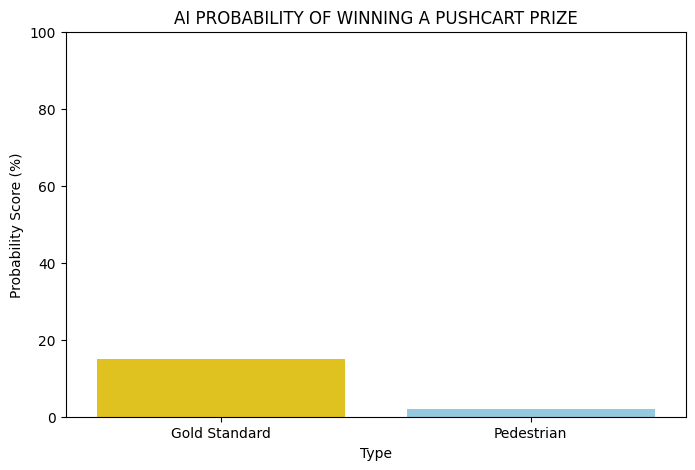


>>> AVG GOLD SCORE: 15.0%
>>> AVG PEDESTRIAN SCORE: 2.0%


In [10]:
# ============================================================================
# STEP 7: BATCH EVALUATION & VALIDATION (THE FINAL VERDICT)
# ============================================================================
print("\n[STEP 7] BATCH EVALUATION: GOLD VS PEDESTRIAN")
print("-" * 80)

import re

# 1. HELPER: EXTRACT SCORE
def extract_percentage(text):
    match = re.search(r'SCORE:\s*(\d+)', text, re.IGNORECASE)
    if match: return int(match.group(1))
    return 0

# 2. SELECT SAMPLES (Top 3 Gold vs Top 3 Pedestrian)
gold_samples = df[df['type']=='Gold Standard'].head(3)
ped_samples = df[df['type']=='Pedestrian'].head(3)
batch = pd.concat([gold_samples, ped_samples])

results = []
print(f"Processing {len(batch)} poems through the Fractal Judge...")

for index, row in batch.iterrows():
    poem_type = row['type']
    poem_text = row['text']

    try:
        # Run Fractal Judge
        raw_output = rank_poem_fractal(poem_text)
        score = extract_percentage(raw_output)

        # Save Result
        results.append({
            "Type": poem_type,
            "Snippet": poem_text[:40].replace('\n', ' ') + "...",
            "AI Score": score,
            "Verdict": raw_output.split("VERDICT:")[-1].strip()[:100]
        })
    except Exception as e:
        print(f"  Error: {e}")

# 3. SHOW FINAL LEADERBOARD
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("FINAL POETRY LEADERBOARD")
print("="*80)
print(df_results[['Type', 'AI Score', 'Verdict']].to_markdown(index=False))

# 4. VISUALIZE
plt.figure(figsize=(8, 5))
try:
    sns.barplot(data=df_results, x='Type', y='AI Score', palette=['gold', 'skyblue'], errorbar=None)
    plt.title("AI PROBABILITY OF WINNING A PUSHCART PRIZE")
    plt.ylabel("Probability Score (%)")
    plt.ylim(0, 100)
    plt.show()
except: pass

# 5. CONCLUSION
avg_gold = df_results[df_results['Type']=='Gold Standard']['AI Score'].mean()
avg_ped = df_results[df_results['Type']=='Pedestrian']['AI Score'].mean()
print(f"\n>>> AVG GOLD SCORE: {avg_gold:.1f}%")
print(f">>> AVG PEDESTRIAN SCORE: {avg_ped:.1f}%")